<a href="https://colab.research.google.com/github/AyaAbdElNaem/Deep_Learning/blob/main/Task_Week3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [14]:
!pip install git+https://github.com/tensorflow/docs

  Cloning https://github.com/tensorflow/docs to /tmp/pip-req-build-9gevkusk
  Running command git clone --filter=blob:none --quiet https://github.com/tensorflow/docs /tmp/pip-req-build-9gevkusk
  Resolved https://github.com/tensorflow/docs to commit 0054afff57cd4a4ea5389088a89942603461ee6f
  Preparing metadata (setup.py) ... done


In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# tensorflow libraries
import tensorflow as tf
from tensorflow import keras
import tensorflow_docs as tfdocs
from tensorflow.keras import layers, models
from tensorflow.keras.layers import Input, Dense

In [16]:
data_url = "http://lib.stat.cmu.edu/datasets/boston"
raw_df = pd.read_csv(data_url, sep=r"\s+", skiprows=22, header=None)
data = np.hstack([raw_df.values[::2, :], raw_df.values[1::2, :2]])
target = raw_df.values[1::2, 2]

# Create a dictionary-like object to mimic the original boston dataset structure
# This is done to maintain compatibility with downstream code that might expect 'data' and 'target' attributes
boston = type('BostonDataset', (object,), {})
boston.data = data
boston.target = target
boston.feature_names = [
    'CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT'
]
boston.DESCR = """Boston house prices dataset (fetched from original source)"""

features = np.array(boston.data)
target = np.array(boston.target)

In [17]:
n_training_samples = features.shape[0]
n_dim = features.shape[1]

print('The dataset has', n_training_samples, 'training samples.')
print('The dataset has', n_dim, 'features.')

The dataset has 506 training samples.
The dataset has 13 features.


In [18]:
def normalize(dataset):
    mu = np.mean(dataset, axis = 0)
    sigma = np.std(dataset, axis = 0)
    return (dataset - mu)/sigma

In [19]:
features_norm = normalize(features)

In [20]:
np.random.seed(42)
rnd = np.random.rand(len(features_norm)) < 0.8

train_x = features_norm[rnd]
train_y = target[rnd]
dev_x = features_norm[~rnd]
dev_y = target[~rnd]

print(train_x.shape)
print(train_y.shape)
print(dev_x.shape)
print(dev_y.shape)

(399, 13)
(399,)
(107, 13)
(107,)


Try to determine which architecture (number of layers and number of neurons) is not overfitting the Boston dataset. When the network starts overfitting? Which network would give a good result?

#Regression Model
Because Im Predicting a price (number)

In [21]:
# def build_model(opt):
#   # create model
# 	model = keras.Sequential()
# 	model.add(layers.Dense(15, input_dim = 13, activation = 'relu')) # add first hidden layer and set input dimensions
# 	model.add(layers.Dense(1)) # add output layer
# 	# compile model
# 	model.compile(loss = 'mse', optimizer = opt, metrics = ['mae'])
# 	return model

In [22]:
# model = build_model(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [23]:
def build_model1_3(opt):
    model = keras.Sequential([
        # 1. طبقة المدخلات (The Input Layer)
        # هنا نخبر الموديل أننا سندخل 13 رقماً لكل عينة (بيانات بوسطن)
        layers.Input(shape=(13,)),

        # 2. الطبقات المخفية (Hidden Layers)
        # الآن هذه الطبقات تركز فقط على "التعلم" ولا تشغل بالها بأبعاد المدخلات
        layers.Dense(3, activation='relu'),

        # 3. طبقة المخرجات (Output Layer)
        # نيرون واحد للتنبؤ بالسعر
        layers.Dense(1)
    ])

    # تجميع الموديل
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [40]:
# القيم التي نريد اختبارها
lrs = [0.1,0.01, 0.001, 0.0001]
batches = [16, 32, 64,128]

# قواميس لتخزين النتائج للرسم
lr_results = {}
batch_results = {}

# Freeze batch_size & change learning rate
fixed_batch = 32
for lr in lrs:
    print(f"Training with LR: {lr}...")
    model = build_model1_3(opt=tf.keras.optimizers.Adam(learning_rate=lr))
    history = model.fit(train_x, train_y, validation_data=(dev_x, dev_y),
                        epochs=200, batch_size=fixed_batch, verbose=0)
    lr_results[f'LR_{lr}'] = history.history

# freezw Learning Rate& change batch Size
fixed_lr = 0.001
for b in batches:
    print(f"Training with Batch Size: {b}...")
    model = build_model1_3(opt=tf.keras.optimizers.Adam(learning_rate=fixed_lr))
    history = model.fit(train_x, train_y, validation_data=(dev_x, dev_y),
                        epochs=200, batch_size=b, verbose=0)
    batch_results[f'Batch_{b}'] = history.history

Training with LR: 0.1...
Training with LR: 0.01...
Training with LR: 0.001...
Training with LR: 0.0001...
Training with Batch Size: 16...
Training with Batch Size: 32...
Training with Batch Size: 64...
Training with Batch Size: 128...


In [41]:
def plot_tuning_results(results_dict, title, xlabel):
    plt.figure(figsize=(10, 6))
    for label, losses in results_dict.items():
        plt.plot(losses, label=label)

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Validation Loss (MSE)')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()


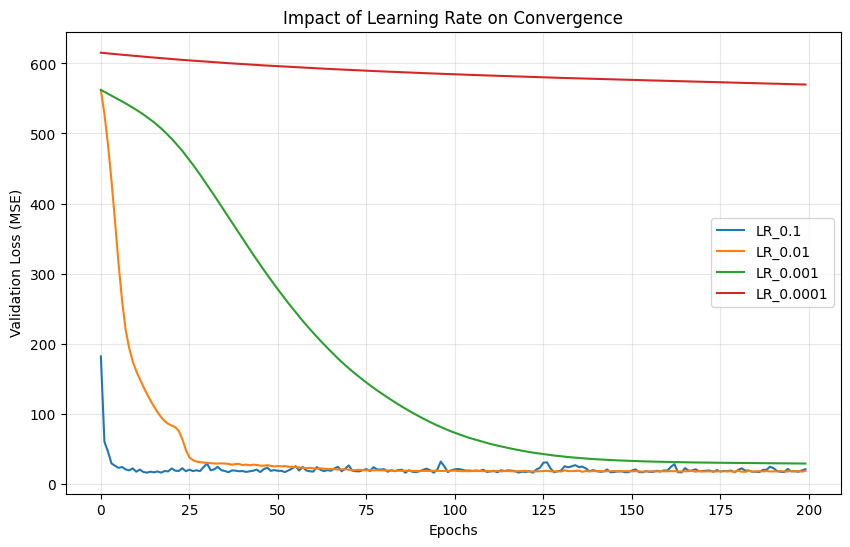

In [42]:
# رسم مقارنة الـ Learning Rates
plot_tuning_results(lr_results, 'Impact of Learning Rate on Convergence', 'Epochs')

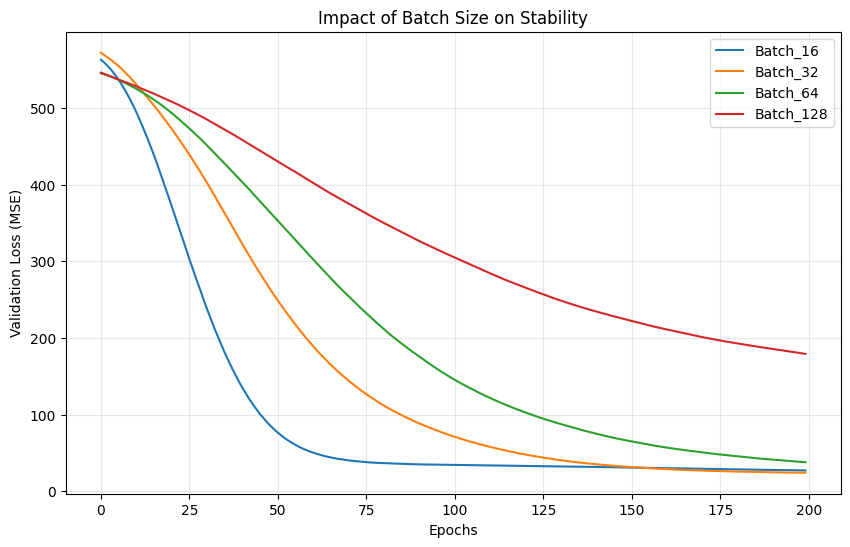

In [44]:
# رسم مقارنة الـ Batch Sizes
plot_tuning_results(batch_results, 'Impact of Batch Size on Stability', 'Epochs')

In [51]:
model1_3 = build_model1_3(opt=tf.keras.optimizers.Adam(learning_rate=0.01))
model1_3.summary()

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_38 (Dense)                │ (None, 3)              │            42 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 46 (184.00 B)

 Trainable params: 46 (184.00 B)

 Non-trainable params: 0 (0.00 B)

In [52]:
history1_3 = model1_3.fit(train_x, train_y, validation_data=(dev_x, dev_y),epochs=200, batch_size=16, verbose=0)

In [55]:
def display_overfitting(history):
    # تحويل بيانات الـ history إلى قاموس لسهولة الوصول
    h = history.history
    epochs = range(len(h['loss']))

    plt.figure(figsize=(10, 6))

    # رسم خطأ التدريب (Train Error)
    # ملاحظة: نستخدم الـ MAE هنا لأنه مقياس الخطأ الذي حددتِه في الموديل
    plt.plot(epochs, h['mae'], 'b-', label='Train Error (MAE)')

    # رسم خطأ التحقق (Validation Error)
    plt.plot(epochs, h['val_mae'], 'r--', label='Validation Error (MAE)')
    plt.title('Overfitting Analysis: Train vs Validation Error')
    plt.xlabel('Epochs')
    plt.ylabel('Mean Absolute Error (MAE)')
    plt.legend()
    plt.grid(True, alpha=0.3)

    plt.show()

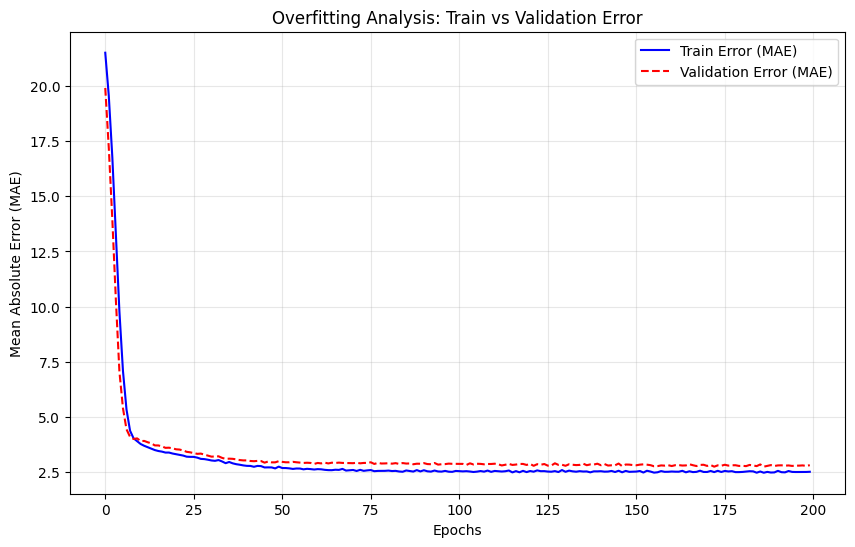

In [56]:
display_overfitting(history1_3)

In [ ]:
def plot_history(history,model_name="Model"):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(12, 5))
    plt.suptitle(f'Training History: {model_name}', fontsize=16)

    # الرسم الخاص بـ Mean Absolute Error
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MAE]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')
    plt.legend()

    # الرسم الخاص بـ Loss
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss [MSE]')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')
    plt.legend()

    plt.show()

In [ ]:
def plot_history_ES(history,model_name="Model"):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    # حساب النقطة التي حققت أقل Loss في بيانات الـ Validation
    # هذه هي النقطة المثالية للتوقف (Early Stopping Point)
    best_epoch = np.argmin(history.history['val_loss'])

    plt.figure(figsize=(12, 5))
    plt.suptitle(f'Training History: {model_name}', fontsize=16)

    # الرسم الخاص بـ Mean Absolute Error
    plt.subplot(1, 2, 1)
    plt.xlabel('Epoch')
    plt.ylabel('Mean Abs Error [MAE]')
    plt.plot(hist['epoch'], hist['mae'], label='Train Error')
    plt.plot(hist['epoch'], hist['val_mae'], label = 'Val Error')

    # إضافة خط عمودي عند أفضل Epoch
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.legend()

    # الرسم الخاص بـ Loss
    plt.subplot(1, 2, 2)
    plt.xlabel('Epoch')
    plt.ylabel('Loss [MSE]')
    plt.plot(hist['epoch'], hist['loss'], label='Train Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Val Loss')

    # إضافة خط عمودي عند أفضل Epoch
    plt.axvline(x=best_epoch, color='red', linestyle='--', label=f'Best Epoch ({best_epoch})')
    plt.legend()

    plt.show()

In [ ]:
plot_history(history1_3,model_name="history1_3")

In [ ]:
plot_history_ES(history1_3)

In [ ]:
def build_model1_5(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(5, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [ ]:
model1_5 = build_model1_5(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [ ]:
model1_5.summary()

In [ ]:
EPOCHS = 500

history1_5 = model1_5.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])

In [ ]:
plot_history(history1_5,model_name="history1_5")

In [ ]:
def build_model2_3(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(3, activation='relu'),
        layers.Dense(3, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [ ]:
model2_3 = build_model2_3(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [ ]:
model2_3.summary()

In [ ]:
EPOCHS = 500

history2_3 = model2_3.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])

In [ ]:
plot_history(history2_3,model_name="history2_3")

In [ ]:
def build_model2_5(opt):
    model = keras.Sequential([
        layers.Input(shape=(13,)),
        layers.Dense(5, activation='relu'),
        layers.Dense(5, activation='relu'),
        layers.Dense(1)])
    model.compile(loss='mse', optimizer=opt, metrics=['mae'])
    return model

In [ ]:
model2_5 = build_model2_5(tf.keras.optimizers.Adam(learning_rate = 0.01))

In [ ]:
model2_5.summary()

In [ ]:
EPOCHS = 500

history2_5 = model2_5.fit(
  train_x, train_y,
  epochs = EPOCHS, verbose = 0,
  validation_data=(dev_x, dev_y),
  batch_size = train_x.shape[0],
  callbacks = [tfdocs.modeling.EpochDots()])

In [ ]:
plot_history(history2_5,model_name="history2_5")

In [ ]:
plot_history_ES(history2_5,model_name="history2_5")

## L2 Regulization